In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/final_financial_data.csv")

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="mixed",
    dayfirst=True
)

print("Dataset Shape:", df.shape)

Dataset Shape: (9802, 25)


In [3]:
df["Year_Month"] = df["Transaction_Date"].dt.to_period("M")

monthly_financials = (
    df.groupby(["Year_Month", "Transaction_Type"])["Amount"]
    .sum()
    .unstack(fill_value=0)
)

monthly_financials.head()

Transaction_Type,Expense,Revenue
Year_Month,,
2021-01,14709639.29,8437831.52
2021-02,14371577.45,11672693.16
2021-03,29949213.44,15201713.77
2021-04,17251021.57,11762185.49
2021-05,18282795.56,9830046.88


In [4]:
expense_series = monthly_financials[["Expense"]].copy()

forecast_df = expense_series.copy()

forecast_df["Lag_1"] = forecast_df["Expense"].shift(1)
forecast_df["Lag_2"] = forecast_df["Expense"].shift(2)
forecast_df["Lag_3"] = forecast_df["Expense"].shift(3)
forecast_df["Lag_12"] = forecast_df["Expense"].shift(12)

forecast_df["Rolling_Mean_3"] = (
    forecast_df["Expense"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

forecast_df["Month"] = forecast_df.index.month
forecast_df["Quarter"] = forecast_df.index.quarter

forecast_df = forecast_df.dropna()

print("Forecast Dataset Shape:", forecast_df.shape)

Forecast Dataset Shape: (48, 8)


In [5]:
train = forecast_df.loc[:'2024']
test = forecast_df.loc['2025']

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 36
Testing observations: 12


In [6]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_12",
    "Rolling_Mean_3",
    "Month",
    "Quarter"
]

X_train = train[features]
y_train = train["Expense"]

X_test = test[features]
y_test = test["Expense"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (36, 7)
y_train: (36,)
X_test: (12, 7)
y_test: (12,)


In [7]:
baseline_predictions = X_test["Lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 10978071.885833336
Baseline RMSE: 13002150.471686438


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [9]:
rf_predictions = rf_model.predict(X_test)

rf_predictions[:5]

array([33546781.1454    , 29417834.94340001, 34775939.89100002,
       38479743.96360003, 32764364.77745003])

In [10]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 5613767.336216655
Random Forest RMSE: 7038432.490276965


In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Baseline,1.097807e+07,1.300215e+07
1,Random Forest,5.613767e+06,7.038432e+06


In [12]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Lag_12,0.483538
2,Lag_3,0.221332
4,Rolling_Mean_3,0.142437
0,Lag_1,0.068376
5,Month,0.050157
1,Lag_2,0.024168
6,Quarter,0.009992


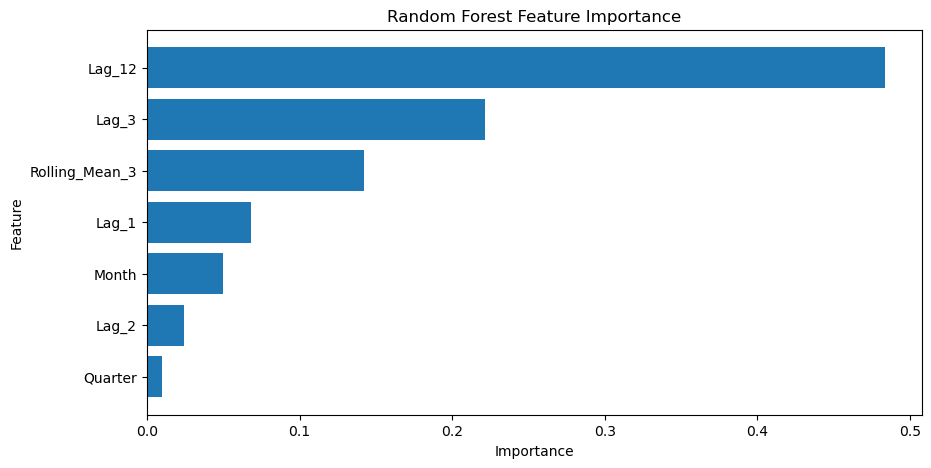

In [13]:
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=200,
                          random_state=42)

In [15]:
gb_predictions = gb_model.predict(X_test)

gb_predictions[:5]

array([33509742.99678089, 30925643.4420548 , 38633017.29567911,
       35760660.20842601, 34078555.67626772])

In [16]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 5313363.5057108225
Gradient Boosting RMSE: 6811377.096450046


In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        gb_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Baseline,1.097807e+07,1.300215e+07
1,Random Forest,5.613767e+06,7.038432e+06
2,Gradient Boosting,5.313364e+06,6.811377e+06


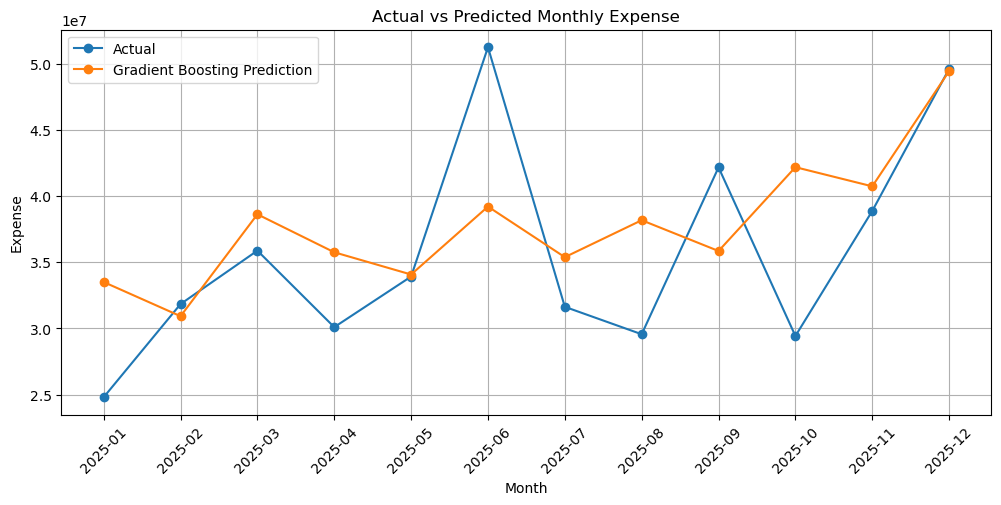

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index.astype(str),
    y_test,
    marker="o",
    label="Actual"
)

plt.plot(
    test.index.astype(str),
    gb_predictions,
    marker="o",
    label="Gradient Boosting Prediction"
)

plt.title("Actual vs Predicted Monthly Expense")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [19]:
comparison.to_csv(
    "../data/processed/forecasting_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [20]:
import joblib

joblib.dump(
    gb_model,
    "../models/gradient_boosting_expense_model.pkl"
)

print("Gradient Boosting model saved successfully.")

Gradient Boosting model saved successfully.
